# Imports and utility functions

In [1]:
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import time, glob, gc, os
import pandas as pd
import seaborn as sns
import xarray as xr
import scanpy as sc
from tqdm import tqdm as pb
import vima.data.ingest as vi

# Set up inputs to preprocessing

In [6]:
# parameters
resolution = 10 # desired size of each pixel in microns
nmetamarkers = 10
repname = f'pca_k={nmetamarkers}_harmony'

# data location
rootdir = f'../../ALZ/alz-data'
outdir = f'{rootdir}/{resolution}u'

# Downsample original images

In [8]:
# define which files we will preprocess and where they'll go
files = glob.glob(f'{rootdir}/raw/middle-temporal-gyrus/*/*/cellpose-detected_transcripts.csv')
countsdir = f'{outdir}/counts'
os.makedirs(countsdir, exist_ok=True)

In [ ]:
import time
for file in files:
    print(f'Processing {file}')
    donor = file.split('/')[-3]
    sid = file.split('/')[-2]
    
    print('\tReading data')
    start_time = time.time()
    data = pd.read_csv(file)
    print(f'Elapsed time: {time.time() - start_time} seconds')
    print('\tNumber of transcripts:', len(data))
    
    # process data
    print('\tMaking pixel list')
    pl = vi.transcriptlist_to_pixellist(
        data,
        x_colname='global_x',
        y_colname='global_y',
        gene_colname='gene',
        pixel_size=resolution
    )
    markers = pl.columns[2:]
    print(len(markers), 'genes')
    
    print('\tMaking pixel matrix')
    s = vi.pixellist_to_pixelmatrix(pl, markers)
    s.name = f'{donor}_{sid}'
    
    # write
    print('\tWriting data')
    compression = {'zlib': True, 'complevel': 2}
    s.astype(np.float32).to_netcdf(f'{countsdir}/{donor}_{sid}.nc', encoding={s.name: compression}, engine="netcdf4")
    gc.collect()

# Preprocess

reading H21.33.011_1217500814
124804 of 605132 (21%) pixels are non-empty
reading H21.33.019_1238559004
71618 of 686169 (10%) pixels are non-empty
reading H20.33.004_1185930850
93427 of 690690 (14%) pixels are non-empty
reading H21.33.028_1195927756
44817 of 493520 (9%) pixels are non-empty
reading H20.33.040_1195928136
135691 of 563140 (24%) pixels are non-empty
reading H21.33.011_1217500810
128120 of 599012 (21%) pixels are non-empty
reading H21.33.001_1192523789
221775 of 807744 (27%) pixels are non-empty
reading H20.33.004_1185930845
131713 of 978460 (13%) pixels are non-empty
reading H20.33.002_1217501029
177828 of 946476 (19%) pixels are non-empty
reading H21.33.040_1296199308
81803 of 1032480 (8%) pixels are non-empty
reading H21.33.006_1175046730
75449 of 610436 (12%) pixels are non-empty
reading H21.33.006_1175046724
64172 of 533368 (12%) pixels are non-empty
reading H21.33.013_1116997297
51967 of 420980 (12%) pixels are non-empty
reading H21.33.005_1217500871
48535 of 569178 

100%|███████████████████████████████████████████████████████████████| 75/75 [01:01<00:00,  1.23it/s]


computing sumstats
normalizing and writing


100%|███████████████████████████████████████████████████████████████| 75/75 [03:06<00:00,  2.48s/it]


...........................................................................merging and standardizing metapixels


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(21294616, 180)
performing PCA


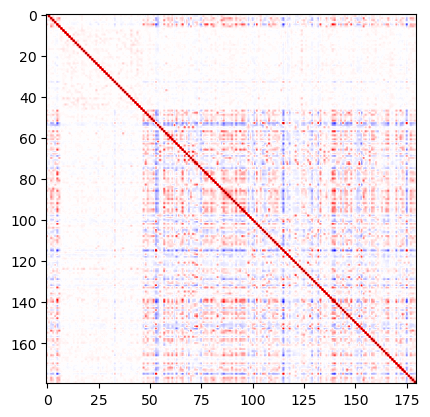

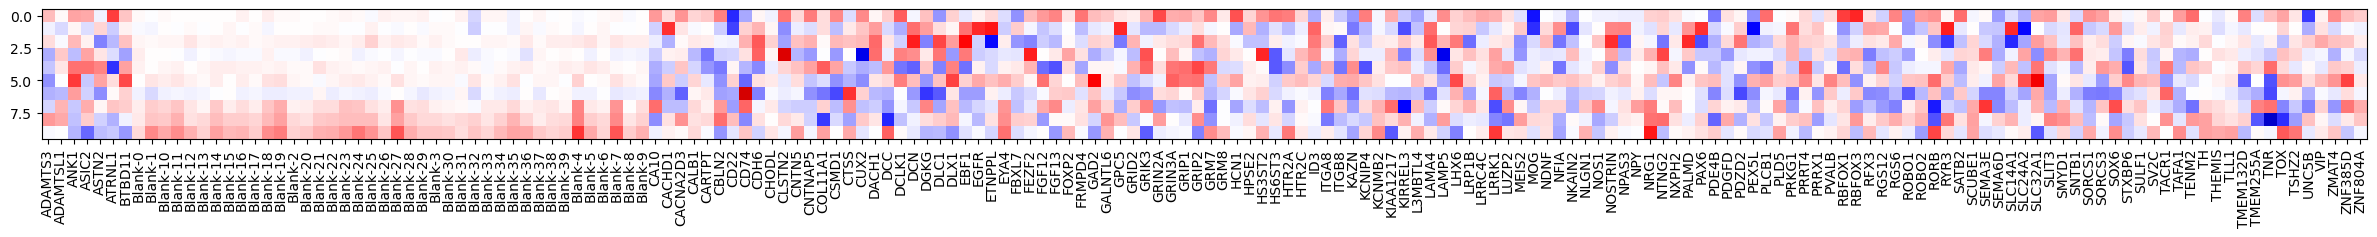

reading in pixels


100%|███████████████████████████████████████████████████████████████| 75/75 [01:13<00:00,  1.03it/s]


applying dimensionality reduction
visualizing


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


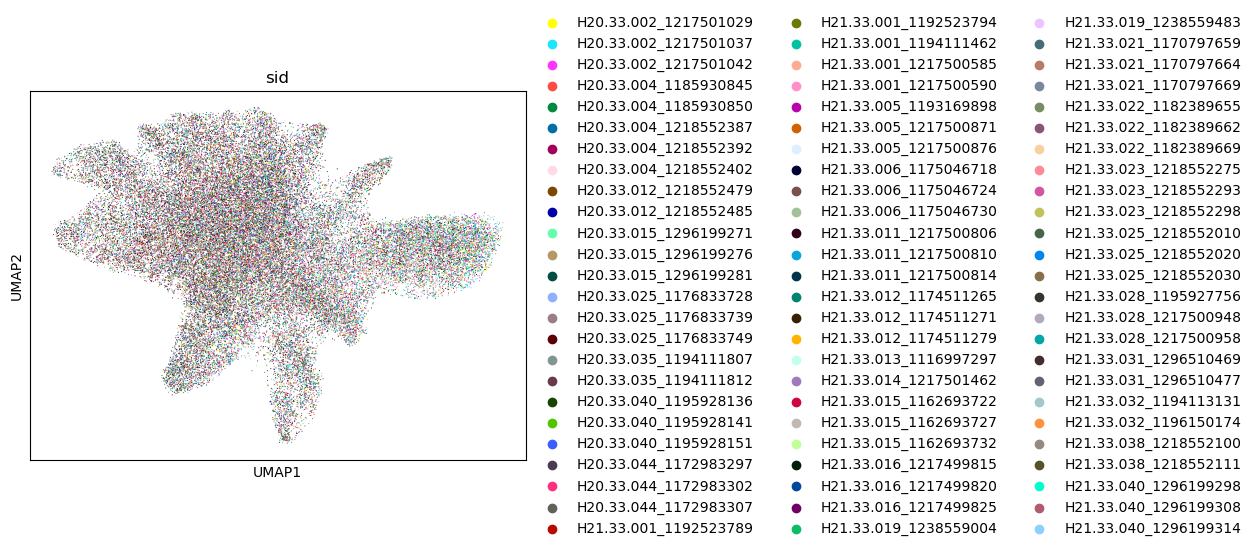

Please run the following command in your R environment:
Rscript /Users/yakir/Dropbox/py/vima/data/harmonize.R /Users/yakir/ST/ALZ/alz-data/10u/pca_k=10_harmony/_allpixels_pca.feather sid

When this finishes, run vi.post_harmony


In [4]:
# pre-harmony processing
vi.preprocess(outdir, repname, vi.foreground_mask_st, vi.get_sumstats_st, vi.normalize_st, nmetamarkers=nmetamarkers)

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


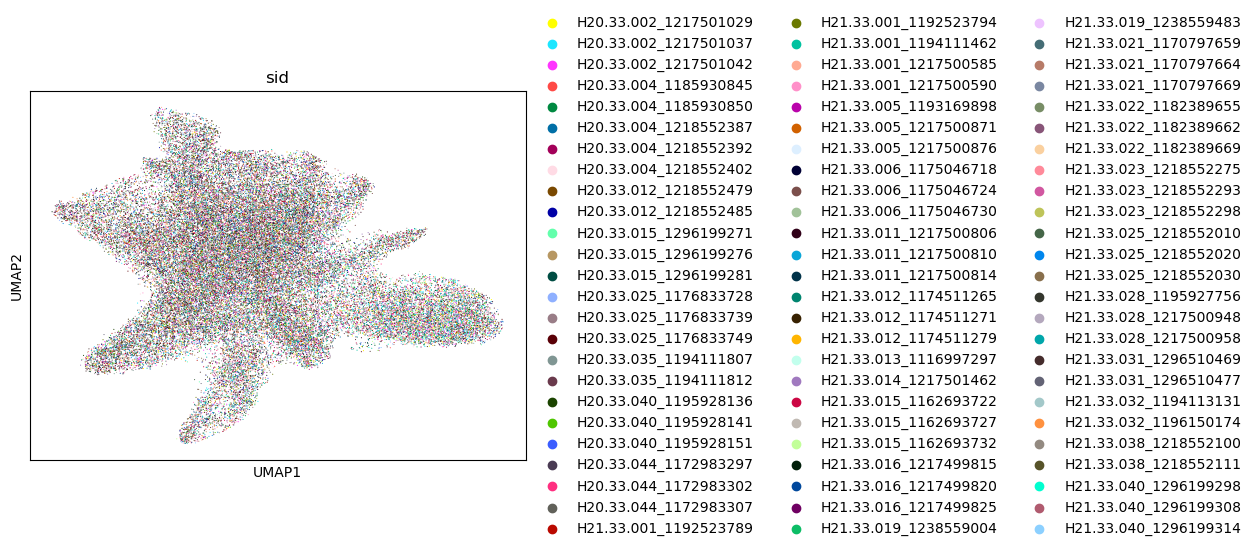

100%|███████████████████████████████████████████████████████████████| 75/75 [00:47<00:00,  1.58it/s]


In [13]:
# post-harmony processing
vi.post_harmony(outdir, repname, plot=True)

all PCs of one sample
histogram of each pc
0123456789

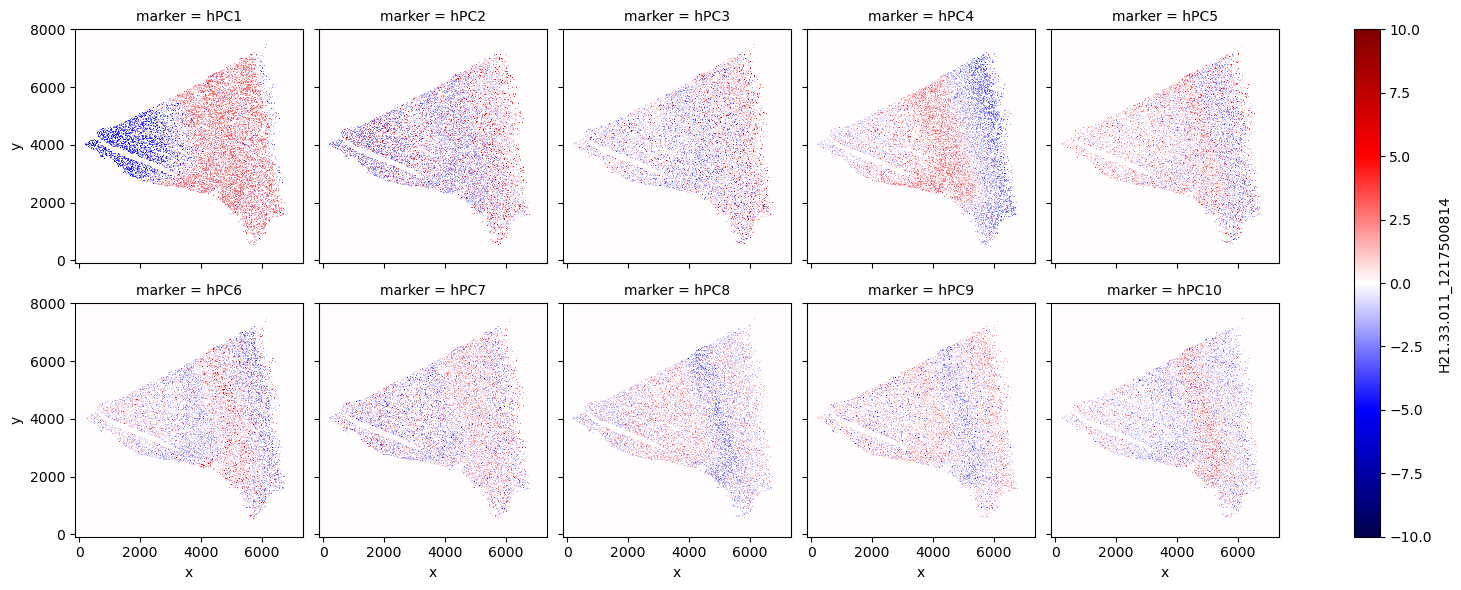

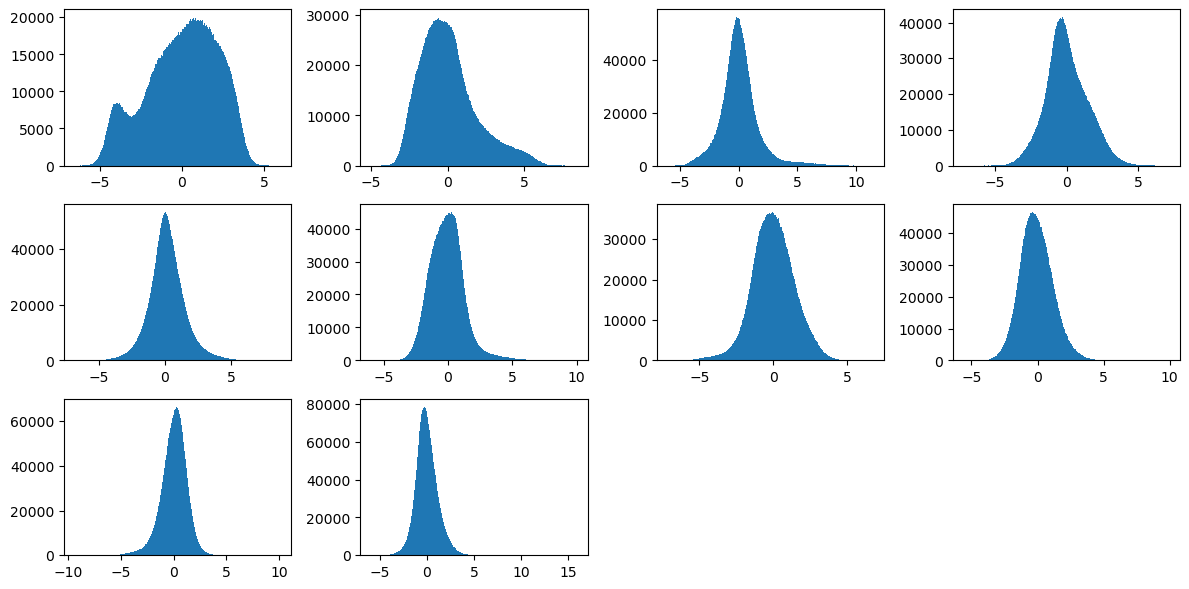

PC1 of several samples


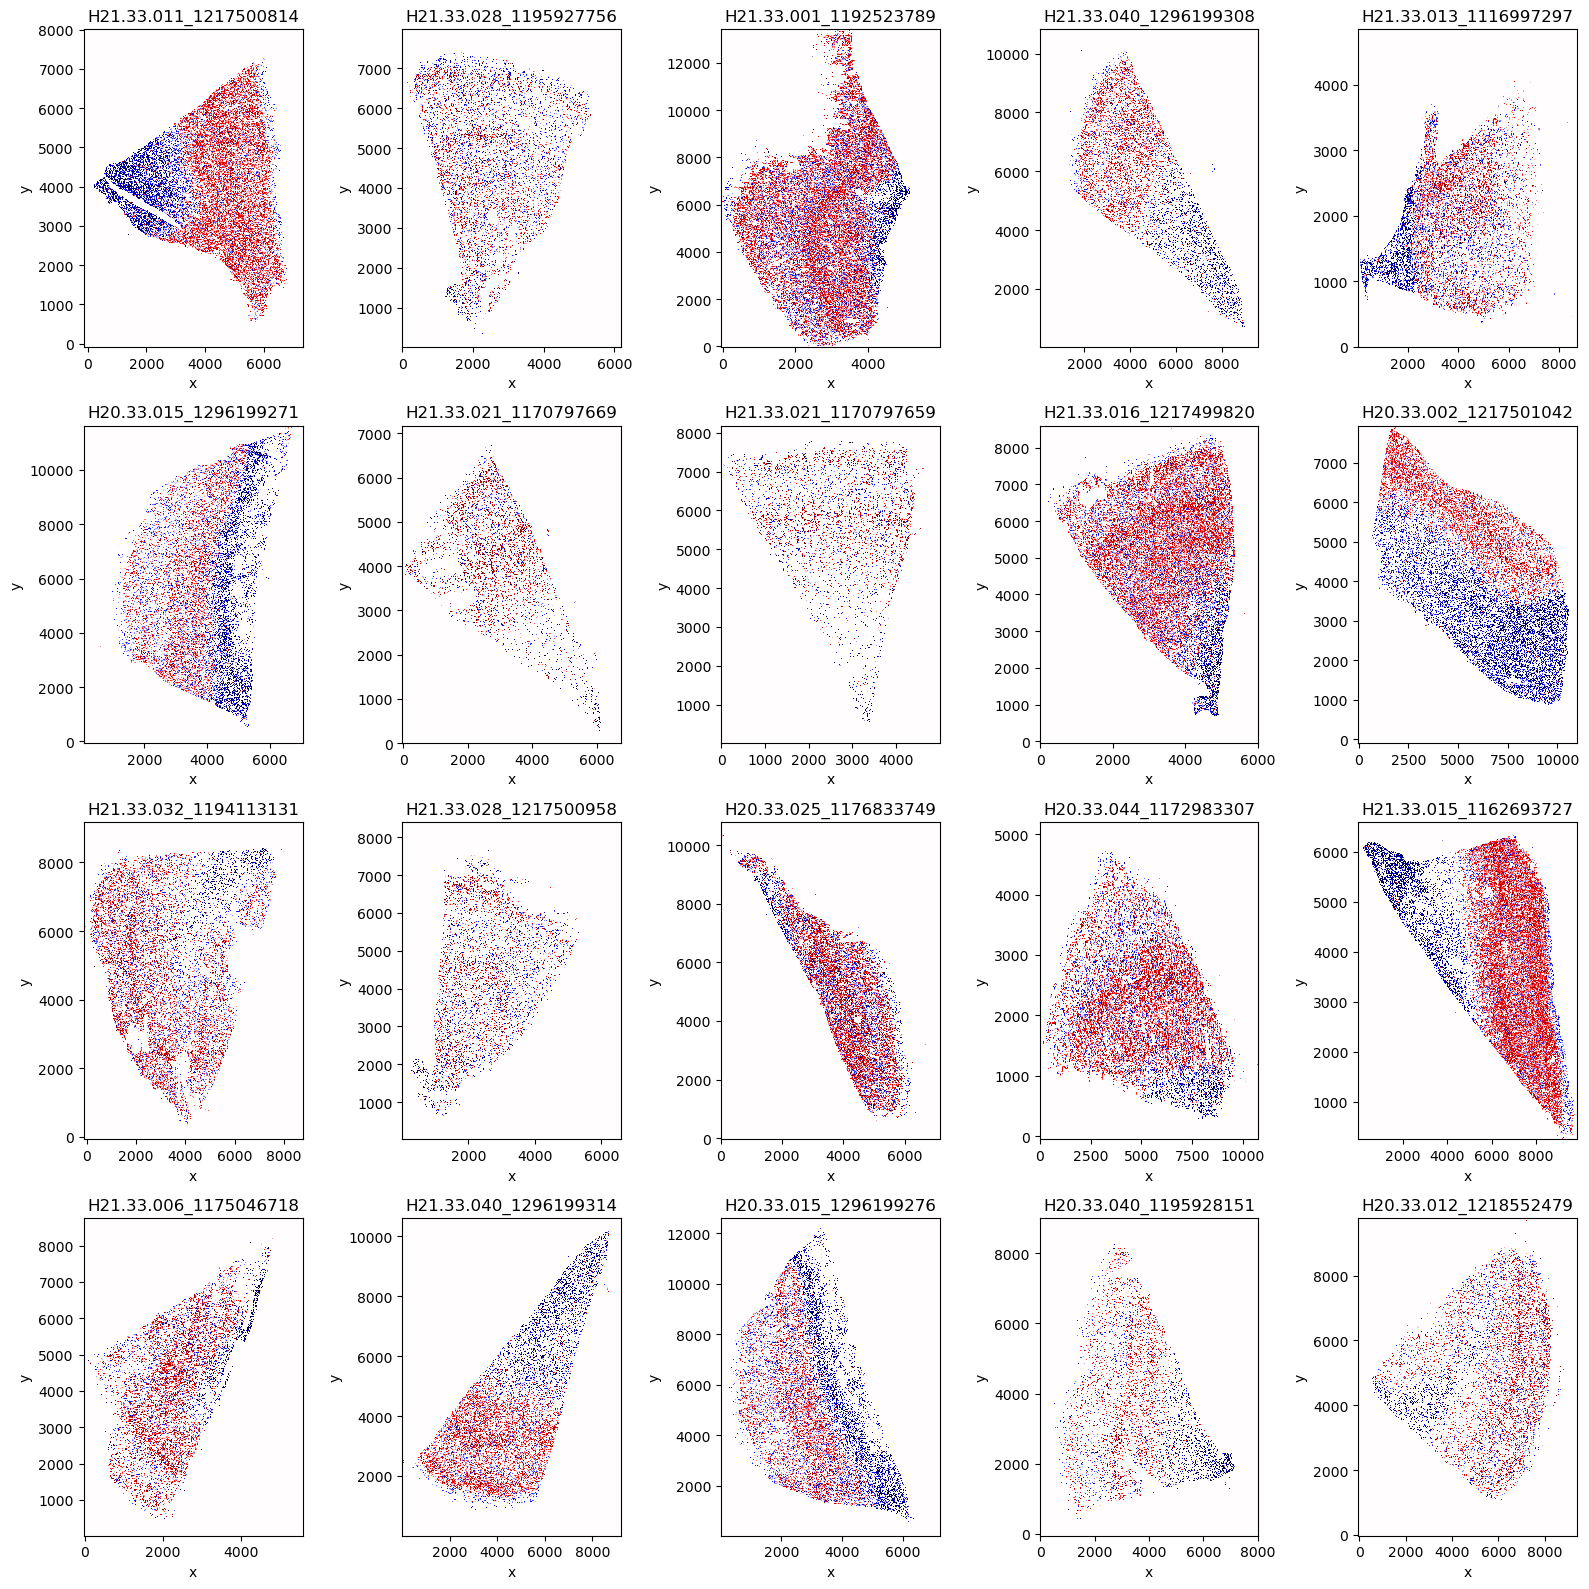

In [14]:
# visual sanity checks
vi.sanity_checks(outdir, repname)